**Parte V** - *¿qué tan bien describe ese modelo la realidad?*

**Bloque B:** ¿Cómo los parámetros estructurales determinan el comportamiento cíclico de la cuenta corriente?

Dotaciones (sin inversión)          corr(CA/PIB, ŷ) = +0.318
Producción (con inversión)          corr(CA/PIB, ŷ) = -0.033


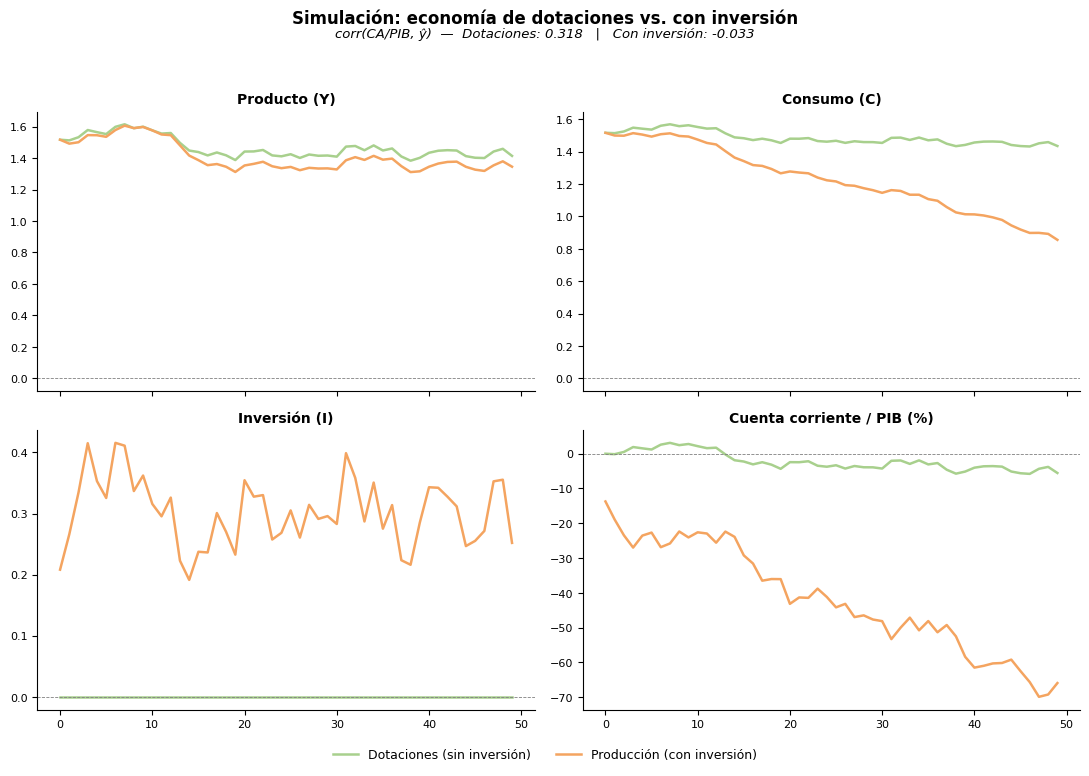

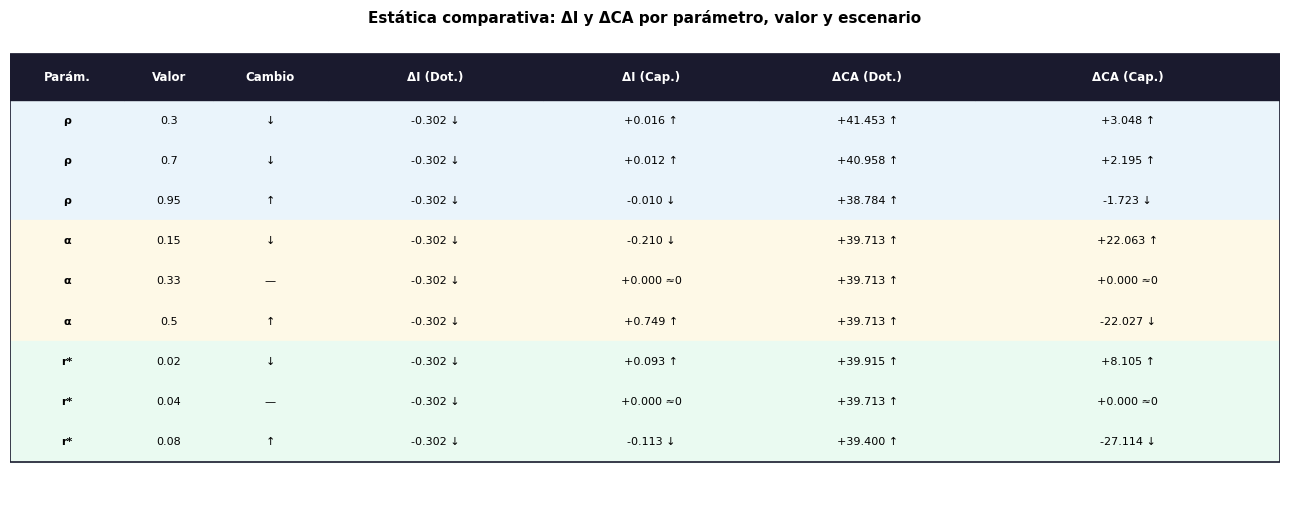

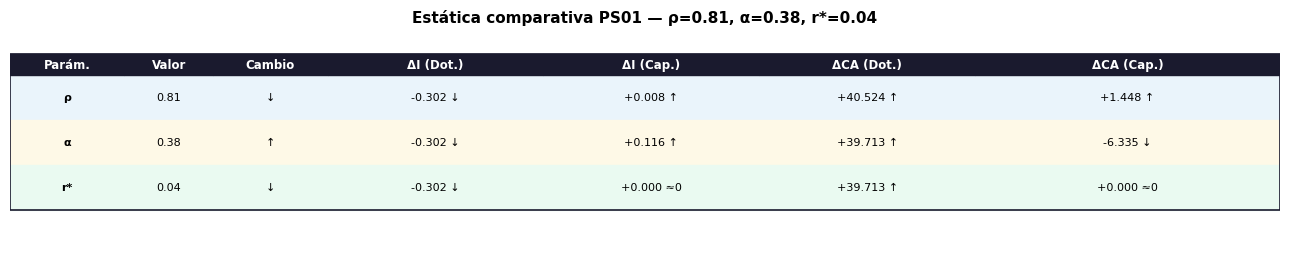

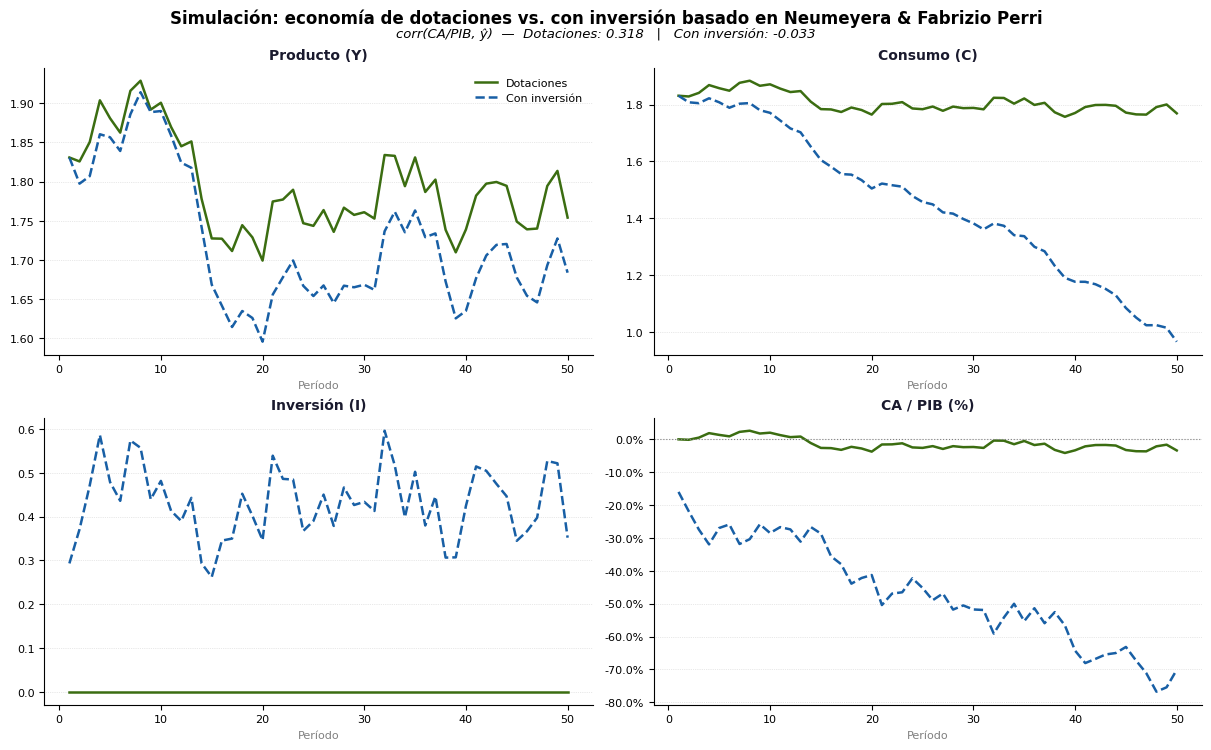


corr(CA/PIB, ŷ) — Dotaciones    : 0.4532
corr(CA/PIB, ŷ) — Con inversión : -0.0548


In [ ]:
# ----------------------------------------------------------------------------
# |                    BLOQUE B                                              |
# ----------------------------------------------------------------------------

import numpy as np
import pandas as pd
from statsmodels.tsa.filters.hp_filter import hpfilter
import matplotlib.pyplot as plt
import matplotlib as mpl # Added this import


       # -----------------------------------------------  #
       # |         Código base del Problem Set          | #
       # -----------------------------------------------  #

def simular_economia(alpha=0.33, beta=0.96, delta=0.10, r_star=0.04,
                     rho=0.90, sigma_eps=0.02, T=50, seed=42,
                     con_inversion=True):

    """
    Simula una economía pequeña y abierta por T periodos.
      con_inversion=False → economía de dotaciones puras (I=0 siempre)
      con_inversion=True  → economía con producción y capital físico
    Retorna un DataFrame con Y, C, I, S, CA, TB y sus ratios sobre PIB.
    """

    np.random.seed(seed)
    eps  = np.random.normal(0, sigma_eps, T)

    # -- Proceso AR(1) para la productividad total de factores (PTF)
    ln_A = np.zeros(T)
    for t in range(1, T):
        ln_A[t] = rho * ln_A[t-1] + eps[t]
    A = np.exp(ln_A)

    # -- Estado estacionario (básicamente un punto de partida)
    k_ss = (alpha / (1/beta - 1 + delta)) ** (1/(1-alpha))
    y_ss = k_ss ** alpha
    c_ss = y_ss - delta * k_ss

    # -- Inicializar trayectorias
    k = np.zeros(T+1);  k[0] = k_ss   # capital (T+1 porque k_{t+1} se guarda)
    b = np.zeros(T+1);  b[0] = 0       # activos externos netos
    y = np.zeros(T);    c = np.zeros(T)
    i = np.zeros(T)

    # -- Simulación periodo a periodo
    for t in range(T):

        # Producto: función de producción si hay capital, dotación pura si no
        y[t] = (A[t] * k[t]**alpha) if con_inversion else (y_ss * A[t])

        if con_inversion:
            # Capital óptimo estático + ajuste parcial (suaviza la inversión)
            k_opt    = (alpha * A[t] / (r_star + delta)) ** (1/(1-alpha))
            k[t+1]   = 0.5 * k_opt + 0.5 * (1 - delta) * k[t]
            i[t]     = k[t+1] - (1 - delta) * k[t]   # inversión neta
        else:
            k[t+1] = k[t]   # sin acumulación de capital
            i[t]   = 0       # sin inversión

        # Consumo: regla de Euler simplificada con suavizamiento intertemporal
        c[t]   = (1/(1+beta)) * (y[t] + r_star*b[t] + beta*y_ss)

        # Ley de movimiento de activos externos (restricción presupuestaria)
        b[t+1] = (1 + r_star)*b[t] + y[t] - c[t] - i[t]

    # -- Variables derivadas
    CA = b[1:] - b[:-1]          # cuenta corriente = cambio en activos ext.
    TB = y - c - i               # balanza comercial
    S  = y + r_star*b[:-1] - c  # ahorro nacional

    return pd.DataFrame({
        "Y": y, "C": c, "I": i, "S": S, "CA": CA, "TB": TB,
        "CA_Y": CA/y*100, "TB_Y": TB/y*100,
        "I_Y":  i/y*100,  "S_Y":  S/y*100
    })


       # -----------------------------------------------  #
       # |             Iteración de modelo              | #
       # -----------------------------------------------  #

# Diccionario de escenarios:

escenarios = {
    "Dotaciones\n(sin inversión)": False,   # con_inversion=False
    "Producción\n(con inversión)": True,    # con_inversion=True
}

sims    = {}   # almacena el DataFrame de cada escenario
ciclos  = {}   # almacena el ciclo HP del producto
corrs   = {}   # almacena corr(CA/PIB, ŷ)

for etiqueta, flag in escenarios.items():

    # 1. Simular
    df = simular_economia(con_inversion=flag)

    # 2. Filtro HP sobre el producto (log, λ=6.25 para datos anuales)
    _, trend = hpfilter(np.log(df["Y"]), lamb=6.25)
    cycle    = np.log(df["Y"]) - trend        # componente cíclico

    # 3. Correlación corr(CA/PIB, ciclo del producto)
    corr_CA = pd.Series(cycle).corr(df["CA_Y"])

    # 4. Acumular
    sims[etiqueta]   = df
    ciclos[etiqueta] = cycle
    corrs[etiqueta]  = corr_CA

    print(f"{etiqueta.replace(chr(10),' '):<35} corr(CA/PIB, ŷ) = {corr_CA:+.3f}")


       # -----------------------------------------------  #
       # |                  Panel 2x2                  | #
       # -----------------------------------------------  #
## 24.

variables = [
    ("Y",    "Producto (Y)"),
    ("C",    "Consumo (C)"),
    ("I",    "Inversión (I)"),
    ("CA_Y", "Cuenta corriente / PIB (%)"),
]

COLOR_DOT = "#A8D08D"   # verde limón  → dotaciones
COLOR_INV = "#F4A460"   # naranja claro → con inversión

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
axes = axes.flatten()

for ax, (var, titulo) in zip(axes, variables):
    for etiqueta, df in sims.items():
        color = COLOR_DOT if "sin" in etiqueta else COLOR_INV
        ax.plot(df[var], label=etiqueta.replace("\n", " "),
                color=color, linewidth=1.8)

    ax.axhline(0, color="gray", linewidth=0.6, linestyle="--")
    ax.set_title(titulo, fontsize=10, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)

# Leyenda compartida debajo del panel
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04))

# Anotación de correlaciones
fig.text(0.5, 1.01,
         f"corr(CA/PIB, ŷ)  —  "
         f"Dotaciones: {corrs['Dotaciones\n(sin inversión)']:.3f}   |   "
         f"Con inversión: {corrs['Producción\n(con inversión)']:.3f}",
         ha="center", fontsize=9.5, style="italic")

fig.suptitle("Simulación: economía de dotaciones vs. con inversión",
             fontsize=12, fontweight="bold", y=1.05)

plt.tight_layout()
plt.savefig("panel_simulacion.png", dpi=150, bbox_inches="tight")
plt.show()
#---------------------------------------------------------------------------------------

### 25.

# Valores iniciales
BASE = dict(alpha=0.33, beta=0.96, delta=0.10, r_star=0.04,
            rho=0.90,   sigma_eps=0.02, T=50,  seed=42)

# Valores a simular
variantes = {
    "rho":    [0.30, 0.70, 0.95],
    "alpha":  [0.15, 0.33, 0.50],
    "r_star": [0.02, 0.04, 0.08],
}

# Símbolos para la tabla
simbolos = {
    "rho":    "ρ",
    "alpha":  "α",
    "r_star": "r*",
}

# Simulación Incial

df_base = simular_economia(**BASE, con_inversion=True)
I_base  = df_base["I"].mean()
CA_base = df_base["CA_Y"].mean()

#---------------------------------------------------------------------------------------------------------
       # -----------------------------------------------  #
       # |   Bucle de parámetros, valores y escenarios  |                  | #
       # -----------------------------------------------  #

registros = []   # acumulará una fila por cada combinación

for param, valores in variantes.items():
    for val in valores:

        # Construir kwargs: baseline + override del parámetro que varía
        kwargs = {**BASE, param: val}

        for con_inv in [False, True]:
            escenario = "Con inversión" if con_inv else "Dotaciones"

            df  = simular_economia(**kwargs, con_inversion=con_inv)

            # ΔI y ΔCA respecto al baseline con inversión
            delta_I  = df["I"].mean()    - I_base
            delta_CA = df["CA_Y"].mean() - CA_base

            # Correlación corr(CA/PIB, ciclo)
            _, trend = hpfilter(np.log(df["Y"]), lamb=6.25)
            cycle    = np.log(df["Y"]) - trend
            corr_CA  = pd.Series(cycle).corr(df["CA_Y"])

            registros.append({
                "Parám.":    simbolos[param],
                "Valor":     val,
                "Cambio":    "↑" if val > BASE[param] else ("↓" if val < BASE[param] else "—"), ## cambios respecto a los valores baseline, en la tabla de resultados se señala la trayectoria del resultado
                "Escenario": escenario,
                "ΔI":        delta_I,
                "ΔCA":       delta_CA,
                "corr(CA,ŷ)": corr_CA,
            })

df_sens = pd.DataFrame(registros)


       # -----------------------------------------------  #
       # |               Tabla comparativa              | #
       # -----------------------------------------------  #

def signo(val, umbral=0.001):
    if val >  umbral: return "↑"
    if val < -umbral: return "↓"
    return "≈0"

# -- Pivotar df_sens para tener dotaciones y capital en columnas separadas
pivot_I  = df_sens.pivot_table(index=["Parám.","Valor","Cambio"],
                                columns="Escenario", values="ΔI")

pivot_CA = df_sens.pivot_table(index=["Parám.","Valor","Cambio"],
                                columns="Escenario", values="ΔCA")

pivot_I.columns.name  = None
pivot_CA.columns.name = None

# -- Construir filas de la tabla
table_rows = []
param_order = ["ρ","α","r*"]   # orden del PS01

for param in param_order:
    sub_I  = pivot_I.xs(param,  level="Parám.")
    sub_CA = pivot_CA.xs(param, level="Parám.")

    for (val, cambio) in sub_I.index:
        dI_dot  = sub_I.loc[(val, cambio),  "Dotaciones"]
        dI_cap  = sub_I.loc[(val, cambio),  "Con inversión"]
        dCA_dot = sub_CA.loc[(val, cambio), "Dotaciones"]
        dCA_cap = sub_CA.loc[(val, cambio), "Con inversión"]

        table_rows.append([
            param,
            f"{val}",
            cambio,
            f"{dI_dot:+.3f} {signo(dI_dot)}",
            f"{dI_cap:+.3f} {signo(dI_cap)}",
            f"{dCA_dot:+.3f} {signo(dCA_dot)}",
            f"{dCA_cap:+.3f} {signo(dCA_cap)}",
        ])

# -- Tabla visual
headers    = ["Parám.", "Valor", "Cambio",
              "ΔI (Dot.)", "ΔI (Cap.)",
              "ΔCA (Dot.)", "ΔCA (Cap.)"]
col_widths = [0.09, 0.07, 0.09, 0.17, 0.17, 0.17, 0.17]
col_widths[-1] += round(1.0 - sum(col_widths), 6)
col_x = [sum(col_widths[:i]) for i in range(len(col_widths))]

DARK, WHITE, GRAY = "#1a1a2e", "#ffffff", "#f5f5f5"

# Color de bloque por parámetro (agrupa visualmente las filas de cada parámetro)
BLOCK_COLORS = {"ρ": "#EAF4FB", "α": "#FEF9E7", "r*": "#EAFAF1"}

n_rows = len(table_rows)
fig, ax = plt.subplots(figsize=(13, n_rows * 0.42 + 1.4))
ax.axis("off")
fig.suptitle("Estática comparativa: ΔI y ΔCA por parámetro, valor y escenario",
             fontsize=11, fontweight="bold", y=0.98)

top    = 0.88
head_h = 0.10

for header, x, w in zip(headers, col_x, col_widths):
    ax.add_patch(mpl.patches.FancyBboxPatch(
        (x, top), w, head_h, transform=ax.transAxes,
        boxstyle="square,pad=0", color=DARK, zorder=2))
    ax.text(x + w/2, top + head_h/2, header, transform=ax.transAxes,
            ha="center", va="center", fontsize=8.5,
            fontweight="bold", color=WHITE, zorder=3)

# Filas
row_h_ax = top / (n_rows + 1)
for i, row in enumerate(table_rows):
    y_top = top - (i + 1) * row_h_ax
    bg    = BLOCK_COLORS.get(row[0], WHITE)   # color por bloque de parámetro

    ax.add_patch(mpl.patches.FancyBboxPatch(
        (0, y_top), 1.0, row_h_ax, transform=ax.transAxes,
        boxstyle="square,pad=0", color=bg, zorder=1))

    aligns = ["center","center","center","center","center","center","center"]
    for j, (cell, x, w, ha) in enumerate(zip(row, col_x, col_widths, aligns)):
        ax.text(x + w/2, y_top + row_h_ax/2, cell,
                transform=ax.transAxes, ha=ha, va="center",
                fontsize=8, color="black",
                fontweight="bold" if j == 0 else "normal")

# Borde exterior
ax.add_patch(mpl.patches.FancyBboxPatch(
    (0, top - n_rows * row_h_ax), 1.0, head_h + n_rows * row_h_ax,
    transform=ax.transAxes, boxstyle="square,pad=0",
    edgecolor=DARK, facecolor="none", linewidth=1.2, zorder=4))

plt.tight_layout()
plt.savefig("tabla_comparativa_detalle.png", dpi=150, bbox_inches="tight")
plt.show()

#---------------------------------------------------------------------------------------------------------------------------------

#P26 (Utilizando el código base)

#  __________________________________________
# |
# | Modelo BASE LINNE con cambio de parámetros según paper
# |__________________________________________


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from statsmodels.tsa.filters.hp_filter import hpfilter

# ==============================================================================
# Baseline y nuevos parámetros
# ==============================================================================

# ---- Cambios
      # rho =  Persistencia del shock de productividad = Productivity --------------------------------> rho = 0.95
      # alfa =  Participación del capital en la producción = Capital exponent (production) -----------> alpha = 0.38
      # r* =  Tasa de interés mundial = International rate -------------------------------------------> r_star = 0.81

#---- Teniendo en cuenta que la data del paper está en términos trimestrales, se deben convertira anuales

# INTERPRETACIÓN CORRECTA DE LOS PARÁMETROS DEL PAPER:
  # rA (ρ_A) = 0.95  →  persistencia TFP TRIMESTRAL  →  0.95^4 ≈ 0.81 anual
  # α        = 0.38  →  capital share, sin cambio
  # r1       = 0.81  →  persistencia AR(1) de r* TRIMESTRAL, ¡NO es el nivel!
                        # El NIVEL de r* en el paper = 14.8% anual (promedio Argentina)

# NUEVOS PARÁMETROS CORRECTOS PARA MODELO ANUAL:
  # rho    = 0.81  (= 0.95^4, persistencia TFP anualizada)
  # alpha  = 0.38  (sin cambio)
  # r_star = 0.04  (nivel anual estándar, el paper no cambia r* como nivel)





BASE = dict(alpha=0.33, beta=0.96, delta=0.10, r_star=0.04,
            rho=0.90, sigma_eps=0.02, T=50, seed=42)

NUEVOS = dict(rho=0.81, alpha=0.38, r_star=0.04)

# Simulación baseline (referencia para deltas)
df_base = simular_economia(**BASE, con_inversion=True)
I_base  = df_base["I"].mean()
CA_base = df_base["CA_Y"].mean()

# ==============================================================================
# CONSTRUIR df_sens solo con los tres parámetros nuevos
# ==============================================================================
simbolos = {"rho": "ρ", "alpha": "α", "r_star": "r*"}
registros = []

for param, val_nuevo in NUEVOS.items():
    kwargs  = {**BASE, param: val_nuevo}   # solo cambia el parámetro en cuestión
    val_base = BASE[param]
    cambio   = "↑" if val_nuevo > val_base else "↓"

    for con_inv in [False, True]:
        escenario = "Con inversión" if con_inv else "Dotaciones"
        df = simular_economia(**kwargs, con_inversion=con_inv)

        delta_I  = df["I"].mean()    - I_base
        delta_CA = df["CA_Y"].mean() - CA_base

        _, trend = hpfilter(np.log(df["Y"]), lamb=6.25)
        cycle    = np.log(df["Y"]) - trend
        corr_CA  = pd.Series(cycle).corr(df["CA_Y"])

        registros.append({
            "Parám.":     simbolos[param],
            "Valor":      val_nuevo,
            "Cambio":     cambio,
            "Escenario":  escenario,
            "ΔI":         delta_I,
            "ΔCA":        delta_CA,
            "corr(CA,ŷ)": corr_CA,
        })

df_sens = pd.DataFrame(registros)

# ==============================================================================
# TABLA COMPARATIVA (26)
# ==============================================================================
def signo(val, umbral=0.001):
    if val >  umbral: return "↑"
    if val < -umbral: return "↓"
    return "≈0"

pivot_I  = df_sens.pivot_table(index=["Parám.", "Valor", "Cambio"],
                                columns="Escenario", values="ΔI")
pivot_CA = df_sens.pivot_table(index=["Parám.", "Valor", "Cambio"],
                                columns="Escenario", values="ΔCA")
pivot_I.columns.name  = None
pivot_CA.columns.name = None

table_rows  = []
param_order = ["ρ", "α", "r*"]

for param in param_order:
    sub_I  = pivot_I.xs(param,  level="Parám.")
    sub_CA = pivot_CA.xs(param, level="Parám.")

    for (val, cambio) in sub_I.index:
        dI_dot  = sub_I.loc[(val, cambio),  "Dotaciones"]
        dI_cap  = sub_I.loc[(val, cambio),  "Con inversión"]
        dCA_dot = sub_CA.loc[(val, cambio), "Dotaciones"]
        dCA_cap = sub_CA.loc[(val, cambio), "Con inversión"]

        table_rows.append([
            param, f"{val}", cambio,
            f"{dI_dot:+.3f} {signo(dI_dot)}",
            f"{dI_cap:+.3f} {signo(dI_cap)}",
            f"{dCA_dot:+.3f} {signo(dCA_dot)}",
            f"{dCA_cap:+.3f} {signo(dCA_cap)}",
        ])

# ── Figura ───────────────────────────────────────────────────────────────────
headers    = ["Parám.", "Valor", "Cambio",
              "ΔI (Dot.)", "ΔI (Cap.)",
              "ΔCA (Dot.)", "ΔCA (Cap.)"]
col_widths = [0.09, 0.07, 0.09, 0.17, 0.17, 0.17, 0.17]
col_widths[-1] += round(1.0 - sum(col_widths), 6)
col_x = [sum(col_widths[:i]) for i in range(len(col_widths))]

DARK, WHITE = "#1a1a2e", "#ffffff"
BLOCK_COLORS = {"ρ": "#EAF4FB", "α": "#FEF9E7", "r*": "#EAFAF1"}

n_rows = len(table_rows)
fig, ax = plt.subplots(figsize=(13, n_rows * 0.42 + 1.4))
ax.axis("off")
fig.suptitle("Estática comparativa PS01 — ρ=0.81, α=0.38, r*=0.04",
             fontsize=11, fontweight="bold", y=0.98)

top = 0.88; head_h = 0.10

for header, x, w in zip(headers, col_x, col_widths):
    ax.add_patch(mpl.patches.FancyBboxPatch(
        (x, top), w, head_h, transform=ax.transAxes,
        boxstyle="square,pad=0", color=DARK, zorder=2))
    ax.text(x + w/2, top + head_h/2, header, transform=ax.transAxes,
            ha="center", va="center", fontsize=8.5,
            fontweight="bold", color=WHITE, zorder=3)

row_h_ax = top / (n_rows + 1)
for i, row in enumerate(table_rows):
    y_top = top - (i + 1) * row_h_ax
    bg    = BLOCK_COLORS.get(row[0], WHITE)
    ax.add_patch(mpl.patches.FancyBboxPatch(
        (0, y_top), 1.0, row_h_ax, transform=ax.transAxes,
        boxstyle="square,pad=0", color=bg, zorder=1))
    for j, (cell, x, w, ha) in enumerate(
            zip(row, col_x, col_widths,
                ["center"]*len(col_widths))):
        ax.text(x + w/2, y_top + row_h_ax/2, cell,
                transform=ax.transAxes, ha=ha, va="center",
                fontsize=8, color="black",
                fontweight="bold" if j == 0 else "normal")

ax.add_patch(mpl.patches.FancyBboxPatch(
    (0, top - n_rows * row_h_ax), 1.0, head_h + n_rows * row_h_ax,
    transform=ax.transAxes, boxstyle="square,pad=0",
    edgecolor=DARK, facecolor="none", linewidth=1.2, zorder=4))

plt.tight_layout()
plt.savefig("tabla_PS01.png", dpi=150, bbox_inches="tight")
plt.show()


       # -----------------------------------------------  #
       # |                  Panel 2x2                  | #
       # -----------------------------------------------  #

def corr_ca_ciclo(df):
    """Correlación entre CA/PIB y el ciclo del producto (filtro HP, λ=6.25)."""
    _, trend = hpfilter(np.log(df["Y"]), lamb=6.25)
    cycle    = np.log(df["Y"]) - trend
    return pd.Series(cycle).corr(df["CA_Y"])


kwargs_nuevos = {**BASE, **NUEVOS}   # BASE con los tres parámetros sobreescritos

df_dot = simular_economia(**kwargs_nuevos, con_inversion=False)
df_cap = simular_economia(**kwargs_nuevos, con_inversion=True)

corr_dot = corr_ca_ciclo(df_dot)
corr_cap = corr_ca_ciclo(df_cap)

periodos = np.arange(1, BASE["T"] + 1)

DARK, GREEN, BLUE = "#1a1a2e", "#3B6D11", "#185FA5"
GREEN_L, BLUE_L   = "#C0DD97", "#B5D4F4"

paneles = [
    ("Producto (Y)",  "Y",    False),
    ("Consumo (C)",   "C",    False),
    ("Inversión (I)", "I",    False),
    ("CA / PIB (%)",  "CA_Y", True),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)

fig.text(0.5, 1.01,
         f"corr(CA/PIB, ŷ)  —  "
         f"Dotaciones: {corrs['Dotaciones\n(sin inversión)']:.3f}   |   "
         f"Con inversión: {corrs['Producción\n(con inversión)']:.3f}",
         ha="center", fontsize=9.5, style="italic")

fig.suptitle("Simulación: economía de dotaciones vs. con inversión basado en Neumeyera & Fabrizio Perri",
             fontsize=12, fontweight="bold", y=1.05)







for ax, (titulo, var, es_ratio) in zip(axes.flat, paneles):
    serie_dot = df_dot[var]
    serie_cap = df_cap[var]

    ax.plot(periodos, serie_dot, color=GREEN, lw=1.8, label="Dotaciones")
    ax.plot(periodos, serie_cap, color=BLUE,  lw=1.8, ls="--", label="Con inversión")

    ax.set_title(titulo, fontsize=10, fontweight="bold", color=DARK)
    ax.set_xlabel("Período", fontsize=8, color="gray")
    ax.tick_params(labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="lightgray", lw=0.5, ls=":")

    if es_ratio:
        ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.1f%%"))

    if var == "CA_Y":
        ax.axhline(0, color="gray", lw=0.8, ls=":")

axes[0, 0].legend(fontsize=8, frameon=False)

plt.savefig("panel_2x2_PS01.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\ncorr(CA/PIB, ŷ) — Dotaciones    : {corr_dot:.4f}")
print(f"corr(CA/PIB, ŷ) — Con inversión : {corr_cap:.4f}")
















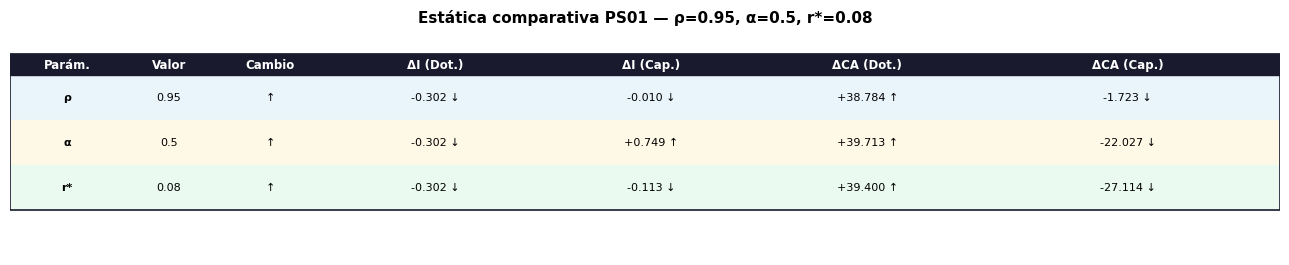

Guardado: tabla_PS01_rho0.95_alpha0.5_r_star0.08.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from statsmodels.tsa.filters.hp_filter import hpfilter

# ==============================================================================
# PARÁMETROS — edita NUEVOS para probar distintas combinaciones
# ==============================================================================
BASE = dict(alpha=0.33, beta=0.96, delta=0.10, r_star=0.04,
            rho=0.90, sigma_eps=0.02, T=50, seed=42)

# ── Cambia estos valores para probar combinaciones ──────────────────────────
NUEVOS = dict(rho=0.95, alpha=0.50, r_star=0.08)   # <-- edita aquí

# ----------------------------------------------------------------------------

# ==============================================================================
# BASELINE
# ==============================================================================
df_base = simular_economia(**BASE, con_inversion=True)
I_base  = df_base["I"].mean()
CA_base = df_base["CA_Y"].mean()

# ==============================================================================
# CONSTRUCCIÓN DE df_sens
# ==============================================================================
simbolos = {"rho": "ρ", "alpha": "α", "r_star": "r*"}
registros = []

for param, val_nuevo in NUEVOS.items():
    kwargs   = {**BASE, param: val_nuevo}
    val_base = BASE[param]
    cambio   = "↑" if val_nuevo > val_base else ("↓" if val_nuevo < val_base else "=")

    for con_inv in [False, True]:
        escenario = "Con inversión" if con_inv else "Dotaciones"
        df = simular_economia(**kwargs, con_inversion=con_inv)

        delta_I  = df["I"].mean()    - I_base
        delta_CA = df["CA_Y"].mean() - CA_base

        _, trend = hpfilter(np.log(df["Y"]), lamb=6.25)
        cycle    = np.log(df["Y"]) - trend
        corr_CA  = pd.Series(cycle).corr(df["CA_Y"])

        registros.append({
            "Parám.":     simbolos[param],
            "Valor":      val_nuevo,
            "Cambio":     cambio,
            "Escenario":  escenario,
            "ΔI":         delta_I,
            "ΔCA":        delta_CA,
            "corr(CA,ŷ)": corr_CA,
        })

df_sens = pd.DataFrame(registros)

# ==============================================================================
# TABLA COMPARATIVA
# ==============================================================================
def signo(val, umbral=0.001):
    if val >  umbral: return "↑"
    if val < -umbral: return "↓"
    return "≈0"

pivot_I  = df_sens.pivot_table(index=["Parám.", "Valor", "Cambio"],
                                columns="Escenario", values="ΔI")
pivot_CA = df_sens.pivot_table(index=["Parám.", "Valor", "Cambio"],
                                columns="Escenario", values="ΔCA")
pivot_I.columns.name  = None
pivot_CA.columns.name = None

param_order = [simbolos[p] for p in NUEVOS.keys()]   # respeta el orden de NUEVOS
table_rows  = []

for param in param_order:
    sub_I  = pivot_I.xs(param,  level="Parám.")
    sub_CA = pivot_CA.xs(param, level="Parám.")

    for (val, cambio) in sub_I.index:
        dI_dot  = sub_I.loc[(val, cambio),  "Dotaciones"]
        dI_cap  = sub_I.loc[(val, cambio),  "Con inversión"]
        dCA_dot = sub_CA.loc[(val, cambio), "Dotaciones"]
        dCA_cap = sub_CA.loc[(val, cambio), "Con inversión"]

        table_rows.append([
            param, f"{val}", cambio,
            f"{dI_dot:+.3f} {signo(dI_dot)}",
            f"{dI_cap:+.3f} {signo(dI_cap)}",
            f"{dCA_dot:+.3f} {signo(dCA_dot)}",
            f"{dCA_cap:+.3f} {signo(dCA_cap)}",
        ])

# ==============================================================================
# FIGURA
# ==============================================================================
titulo = "Estática comparativa PS01 — " + ", ".join(
    f"{simbolos[k]}={v}" for k, v in NUEVOS.items()
)

headers    = ["Parám.", "Valor", "Cambio",
              "ΔI (Dot.)", "ΔI (Cap.)",
              "ΔCA (Dot.)", "ΔCA (Cap.)"]
col_widths = [0.09, 0.07, 0.09, 0.17, 0.17, 0.17, 0.17]
col_widths[-1] += round(1.0 - sum(col_widths), 6)
col_x = [sum(col_widths[:i]) for i in range(len(col_widths))]

DARK, WHITE  = "#1a1a2e", "#ffffff"
BLOCK_COLORS = {"ρ": "#EAF4FB", "α": "#FEF9E7", "r*": "#EAFAF1"}

n_rows = len(table_rows)
fig, ax = plt.subplots(figsize=(13, n_rows * 0.42 + 1.4))
ax.axis("off")
fig.suptitle(titulo, fontsize=11, fontweight="bold", y=0.98)

top = 0.88; head_h = 0.10

for header, x, w in zip(headers, col_x, col_widths):
    ax.add_patch(mpl.patches.FancyBboxPatch(
        (x, top), w, head_h, transform=ax.transAxes,
        boxstyle="square,pad=0", color=DARK, zorder=2))
    ax.text(x + w/2, top + head_h/2, header, transform=ax.transAxes,
            ha="center", va="center", fontsize=8.5,
            fontweight="bold", color=WHITE, zorder=3)

row_h_ax = top / (n_rows + 1)
for i, row in enumerate(table_rows):
    y_top = top - (i + 1) * row_h_ax
    bg    = BLOCK_COLORS.get(row[0], WHITE)
    ax.add_patch(mpl.patches.FancyBboxPatch(
        (0, y_top), 1.0, row_h_ax, transform=ax.transAxes,
        boxstyle="square,pad=0", color=bg, zorder=1))
    for j, (cell, x, w, _) in enumerate(
            zip(row, col_x, col_widths, ["center"]*len(col_widths))):
        ax.text(x + w/2, y_top + row_h_ax/2, cell,
                transform=ax.transAxes, ha="center", va="center",
                fontsize=8, color="black",
                fontweight="bold" if j == 0 else "normal")

ax.add_patch(mpl.patches.FancyBboxPatch(
    (0, top - n_rows * row_h_ax), 1.0, head_h + n_rows * row_h_ax,
    transform=ax.transAxes, boxstyle="square,pad=0",
    edgecolor=DARK, facecolor="none", linewidth=1.2, zorder=4))

# nombre del archivo refleja los parámetros usados
fname = "tabla_PS01_" + "_".join(f"{k}{v}" for k, v in NUEVOS.items()) + ".png"
plt.tight_layout()
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado: {fname}")
